# MNIST
## 08. Data Representation

In [1]:
from infdsa_mnist import mnist_load, mnist_output, decision_tree, data_representation, data_representation_output
from infdsa_mnist.decision_tree import DecisionTreeClassifier

(train_data, test_data) = mnist_load.load_mnist()
x_train, y_train = train_data
x_test, y_test = test_data

full_subset = decision_tree.create_subset(x_train, y_train, subset_size=len(x_train))
demo_image = x_train[0]
demo_label = y_train[0]

In the previous notebook, we have created a simple decision tree. This decision tree effectively trained itself on the embedded device. Due to this, however, it was not possible to properly train the model before deploying it on the device. The limited resources of the embedded device limited us to a basic model. This for now isn't a problem, but from now on, we will presume we can train on a more powerful machine and deploy the trained model on the embedded device. To that end, we will be exploring encoding and data representation techniques, using the main question as a guideline: **How can we represent the data in a way that is as small as possible, while retaining as much information as possible?**

We will break down our exploration into a few main sections:
1. What does the input look like during inference?
2. How much RAM is used to present that input?
3. What ways are there to reduce memory usage?

## What does the input look like during inference?
The embedded device has a 28x28 pixel touchscreen. Each pixel has a value between 0 and 255, representing the intensity of the pixel. This means that the input to our model is a 28x28 matrix of integers between 0 and 255, which is the same as our training data.

## How much RAM is used to present that input?
To represent the input, we need to store the 28x28 matrix in RAM. Each pixel value is an integer between 0 and 255, which can be represented in 8 bits. NumPy enables us to represent this data efficiently using the `uint8` data type, which uses 1 byte (8 bits) per pixel. However, if we want to normalize the pixel values to be between 0 and 1, we would need to use a floating-point representation, which requires 4 bytes (32 bits) per pixel. This means that the memory usage for the input can vary significantly, depending on how we choose to represent the pixel values.

## What ways are there to reduce memory usage?
There are many techniques to reduce memory usage. We will explore a few of these techniques in turn, first visually on a single image, and then by benchmarking them on the full test set. The techniques we will explore are:
- Quantization
- Binary thresholding
- Binning
- Downscaling
- Sparse encoding

There are, of course, many other techniques to reduce memory usage, and the best technique to use will depend on the specific use case and the trade-offs we are willing to make between memory usage and information retention. To illustrate some of these techniques, we will use the decision tree we created in the previous notebook and apply some of these techniques to see how it affects the performance of the model.

### Quantization
Quantization reduces each pixel's precision from 8 bits to a smaller number of bits. In this case, we will quantize the pixel values to 4 bits. Effectively, this means that the range of pixel values goes from (0-255) to (0-15). The overall shape and stroke of the digit is preserved, but finer details get flattened into coarser steps. The memory output is reduced by half.

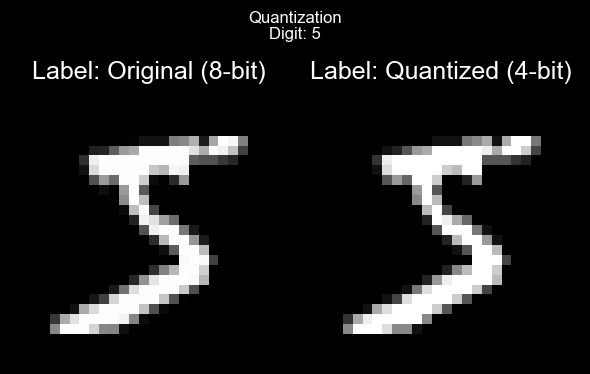

In [2]:
quantized = data_representation.quantize(demo_image)

mnist_output.display_images(
    [demo_image, quantized],
    ["Original (8-bit)", "Quantized (4-bit)"],
    title=f"Quantization\nDigit: {demo_label}"
)

As we can see from the image and the quantized version, once we quantize the image, some of the finer details of the digit are lost. The overall shape and stroke of the digit are preserved, meaning that the quantized image still holds a lot of information about the original image. Reducing the precision to 4 bits, therefore, means we can reduce memory usage by half whilst promising a negligible loss in accuracy. We will see in the benchmarks how this plays out in practice.

### Binary Thresholding
Binary thresholding involves converting each pixel value to 0 or 1 based on a threshold. In this case, we will use a threshold of 128. This means that any pixel value above 128 is set to 1, and any pixel value below or equal to 128 is set to 0.

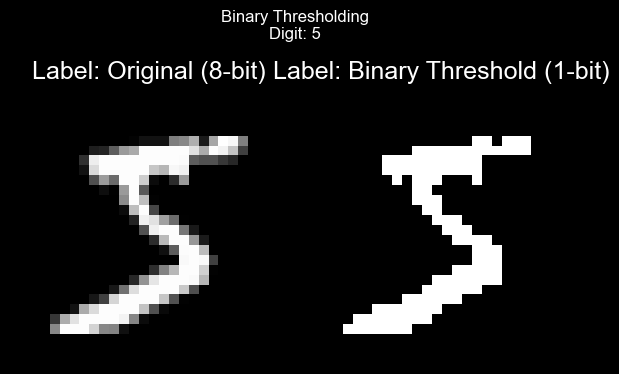

In [3]:
binary_thresholded = data_representation.binary_threshold(demo_image, threshold=128)

mnist_output.display_images(
    [demo_image, binary_thresholded],
    ["Original (8-bit)", "Binary Threshold (1-bit)"],
    title=f"Binary Thresholding\nDigit: {demo_label}"
)


From this example, we can see that the binary thresholding technique reduces the quality of the digit significantly. Though the digit is still recognizable in this example, it is not nearly as clear as the original image. The memory usage is reduced by a factor of 8, which is significant, but it comes at the cost of losing a significant portion of the information.
To be transparent, the simple binary thresholding technique we used is not optimal. With a little more work and time, we can use Otsu's method to automatically determine the optimal threshold based on the images it receives. This will increase the quality somewhat, but it will also increase the complexity of the algorithm, as well as the time it takes to process the image, which may not be ideal for an embedded device. Since we have already implemented Otsu's method within the `data_representation` module, we will show an example below, but we will not be using it in the benchmarks, as it does not increase the quality enough to justify the additional complexity and processing time.

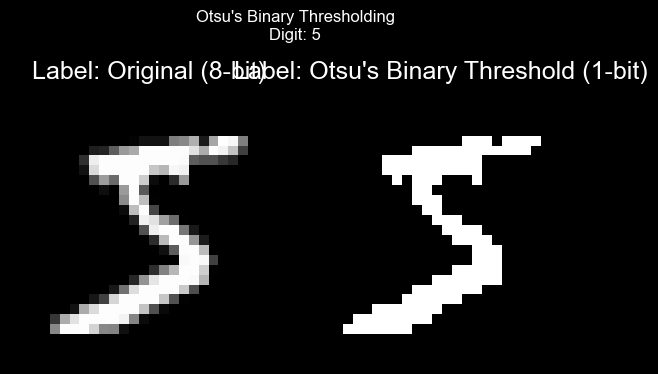

In [4]:
otsu_binary_threshold = data_representation.otsu_binary_threshold(demo_image)

mnist_output.display_images(
    [demo_image, otsu_binary_threshold],
    ["Original (8-bit)", "Otsu's Binary Threshold (1-bit)"],
    title=f"Otsu's Binary Thresholding\nDigit: {demo_label}")

### Binning
Binning groups pixel values into bins. In this scenario, we will group pixel values into 4 bins: 0-63, 64-127, 128-191, and 192-255. This means that any pixel value between 0 and 63 is set to 0, any pixel value between 64 and 127 is set to 1, any pixel value between 128 and 191 is set to 2, and any pixel value between 192 and 255 is set to 3. This allows us to represent each pixel value in just 2 bits, which reduces memory usage by a factor of 4.

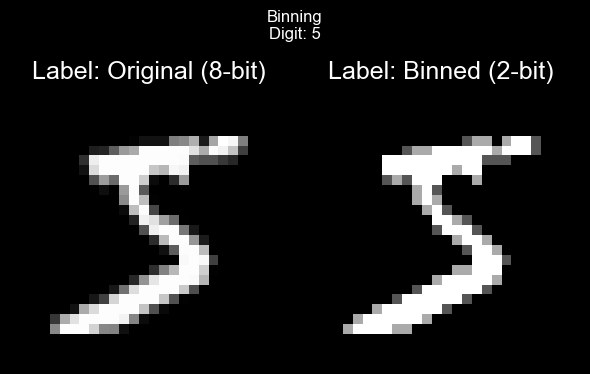

In [5]:
binned = data_representation.bin_pixels(demo_image)

mnist_output.display_images(
    [demo_image, binned],
    ["Original (8-bit)", "Binned (2-bit)"],
    title=f"Binning\nDigit: {demo_label}"
)

The binned image compresses the pixel values into 4 distinct levels. This results in a loss of finer details, but the overall structure of the digit is still preserved. The memory usage is reduced by a factor of 4, which is significant, and the loss of information is not nearly as severe as with binary thresholding. This makes binning a promising technique for reducing memory usage. We will see in the benchmarks how this technique performs in practice.

### Downscaling
Downscaling reduces the resolution of the input image. In the case of MNIST, this means reducing the 28x28 image to a smaller size. In this example, we will downscale the image to half its original size, which is 14x14. This reduces the memory usage by a factor of 4.

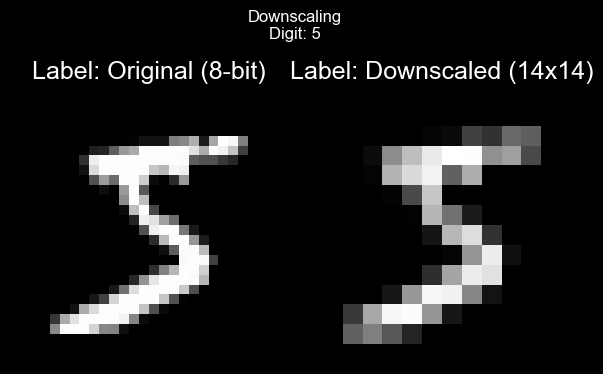

In [6]:
downscaled = data_representation.downscale(demo_image)

mnist_output.display_images(
    [demo_image, downscaled],
    ["Original (8-bit)", "Downscaled (14x14)"],
    title=f"Downscaling\nDigit: {demo_label}"
)

From this example, we can clearly see the impact of downscaling on the image. Each pixel is four times larger than in the original image, which results in a significant loss of detail. The overall shape of the digit is still recognizable, but it is not nearly as clear as the original image. In edge cases, the digit may even become unrecognizable. The memory usage is reduced by a factor of 4, just like with binning, but the loss of information is much more severe. This only serves to illustrate not all techniques work equally well in all cases. In some cases, this technique may be incredibly effective, but in the case of MNIST, it is not ideal at this scale. We will see in the benchmarks how this technique performs in practice. For now, we could consider downscaling to a slightly larger size, such as 20x20, but we will stick with 14x14 for the benchmarks.

### Sparse Encoding
Sparse encoding represents the input image as a sparse matrix, where only the non-zero pixel values are stored. This can be particularly effective given a largely empty image, without removing any information from the image. However, it is not as consistent as other techniques, since it depends on the image's content. In the case of MNIST, many images are quite sparse, with a lot of empty space around the digit, which makes this technique potentially effective.

Original:     784 bytes
Sparse form:  498 bytes (166 non-zero pixels)


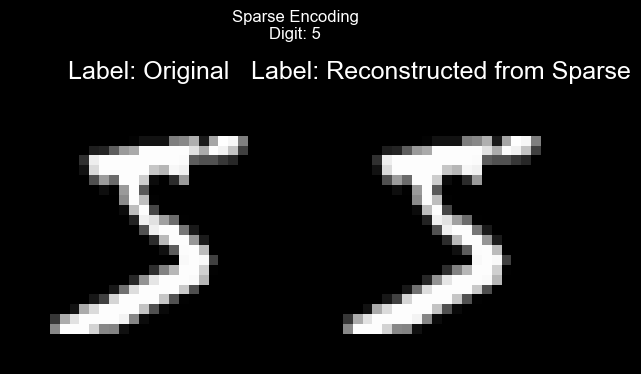

In [7]:
sparse_encoded = data_representation.sparse_encode(demo_image)
reconstructed = data_representation.sparse_decode(sparse_encoded)

print(f"Original:     {demo_image.nbytes} bytes")
print(f"Sparse form:  {sparse_encoded.nbytes} bytes ({len(sparse_encoded)} non-zero pixels)")

mnist_output.display_images(
    [demo_image, reconstructed],
    ["Original", "Reconstructed from Sparse"],
    title=f"Sparse Encoding\nDigit: {demo_label}"
)

Note here that we have to reconstruct the image back to its original 28x28 size before we can display it, since the sparse encoding only stores the non-zero pixel values and their positions. The reconstructed image looks identical to the original image, which means we have not lost any information. As we can see from the memory usage, the sparse encoding reduces the memory usage significantly, from 784 bytes to 498 bytes in this example. However, this is not a consistent reduction, as it depends on the content of the image. We would likely see a much larger reduction on images with a '1' digit compared to images with an '8' digit, for example. We will see in the benchmarks how this averages out across the entire test set.

## Training the Classifier on the Full Dataset
We will now train the classifier on the full training set. In the previous notebook, we were limited to a small subset of the training data, a small subset of the test data, and a limited range of depths to explore. Now that we are no longer limited by these constraints, we can use the full training and test sets and explore a wider range of depths to find the optimal depth for our decision tree, based on our features. This will give us a more accurate picture regarding the performance of our model and allow us to make more informed decisions about the trade-offs between memory usage and accuracy when we apply the encoding techniques. We might also go back and explore different features, but for now, we will stick with the same features we used in the previous notebook.

In [8]:
clf = DecisionTreeClassifier.fit_best_depth(
    full_subset["features"],
    full_subset["labels"],
    x_test,
    y_test,
    depth_range=range(1, 16)
)

clf.save("optimal_tree.pkl")
print(f"RAM estimate:   {clf.ram_usage_kb():.2f} KB")
print(f"Storage size:   {clf.storage_size_kb():.2f} KB")

Depth  1: 20.28%
Depth  2: 33.51%
Depth  3: 36.72%
Depth  4: 40.33%
Depth  5: 42.22%
Depth  6: 46.08%
Depth  7: 49.45%
Depth  8: 52.50%
Depth  9: 54.62%
Depth 10: 55.52%
Depth 11: 56.81%
Depth 12: 56.52%
Depth 13: 54.87%
Depth 14: 52.15%
Depth 15: 48.31%

Best depth: 11 (56.81% accuracy)
Saved to 'optimal_tree.pkl' (134.70 KB)
RAM estimate:   633.91 KB
Storage size:   134.70 KB


Since we can now train using the full training set, it turns out the real optimal depth is 11, reaching 56.81% accuracy. This is a little higher than the 50% accuracy we got in the previous notebook, but more significant considering the increased set of data we are using. The model is also no longer overfitting at a depth of 4. Instead, it starts to overfit at a depth of 12. All of this is a good indication that our model is now more robust to the data it is trained on. It is, however, also clearer now that the features we are using could be improved. By improving the features, we could potentially achieve a higher accuracy at a lower depth, which would improve the model's performance on the device.

The serialized tree is 134.70 KB, which is well within the 1 MB storage limit of the embedded device. It also fits into RAM during inference using `pickle`. This is good news, as this means we can deploy the model on the device without needing to worry about memory constraints or needing to write our own serialization code to further reduce the size. The total storage size of the tree is also a decrease from the previous tree, since the previous tree was not trained whatsoever and needed full images loaded into RAM to train itself on the device. This means it had less knowledge and could not be optimized further than what pre-processing could do. Since we have already made these architectural changes, we know the device can perform more consistently without needing to worry about memory constraints.

## Simulating Device Inference
With the classifier serialized, we now simulate what the embedded device does at runtime: load the tree from storage, receive a single image from the touchscreen, and produce a prediction. Only the tree and one image need to be in RAM at any point.

In [9]:
clf = DecisionTreeClassifier.load("optimal_tree.pkl")

sample_image = x_test[0]
sample_label = y_test[0]

prediction = clf.predict(sample_image)
print(f"True label: {sample_label} | Predicted: {prediction}")

Loaded classifier (depth=11, nodes=4057)
True label: 7 | Predicted: 7


## Benchmarking Encoding Techniques
We will now apply each encoding technique to the full test set and measure two things: how accurate the classifier remains, and how much memory the encoded image requires per sample. The baseline is the raw `uint8` image at 784 bytes. Any technique that reduces memory without significantly hurting accuracy is a candidate for use on the device.

Note that downscaling and sparse encoding require reconstruction back to 28x28 before prediction, since our feature pipeline assumes that input format. The memory figures still reflect the *encoded* size, not the reconstructed one. Do, however, keep in mind that the reconstruction step adds the original memory usage back into RAM during inference, which means the following: the average memory usage gets reduced, but the peak memory usage actually goes up. This is an important consideration, as the embedded device has a hard limit of 256 KB of RAM, meaning that if we go over that limit for even a millisecond, the device will crash.

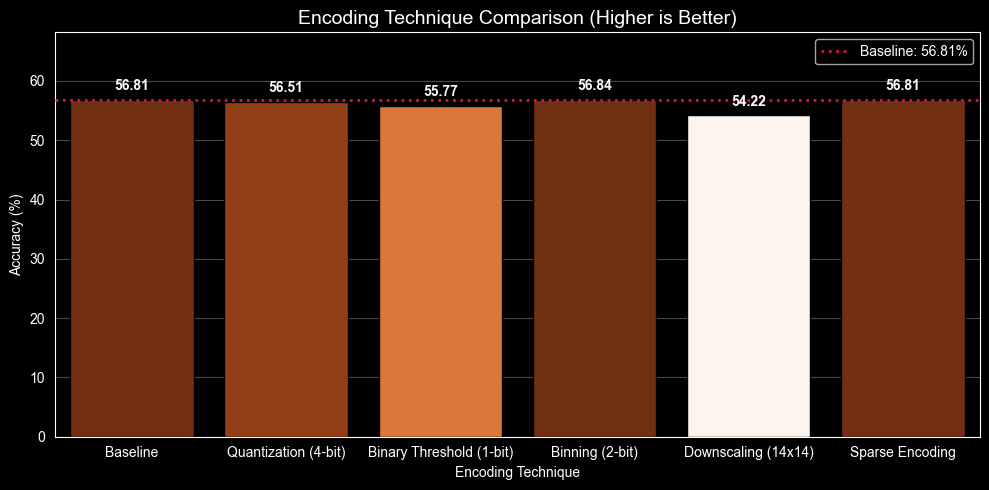

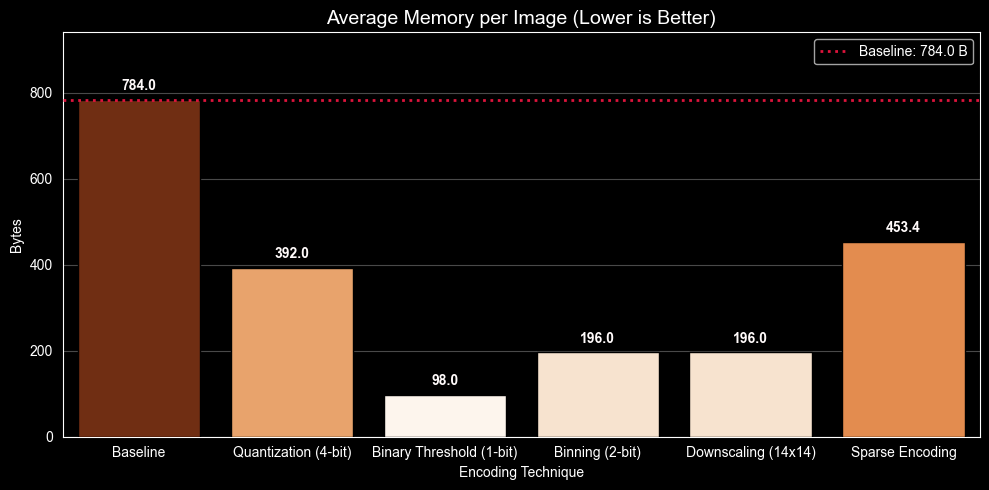

In [10]:
results = data_representation.benchmark_encodings(clf, x_test, y_test)
data_representation_output.plot_encoding_comparison(results)

## Combining Encoding Techniques
Having established the individual trade-offs, we can now explore whether combining
techniques yields further memory savings without compounding accuracy losses.

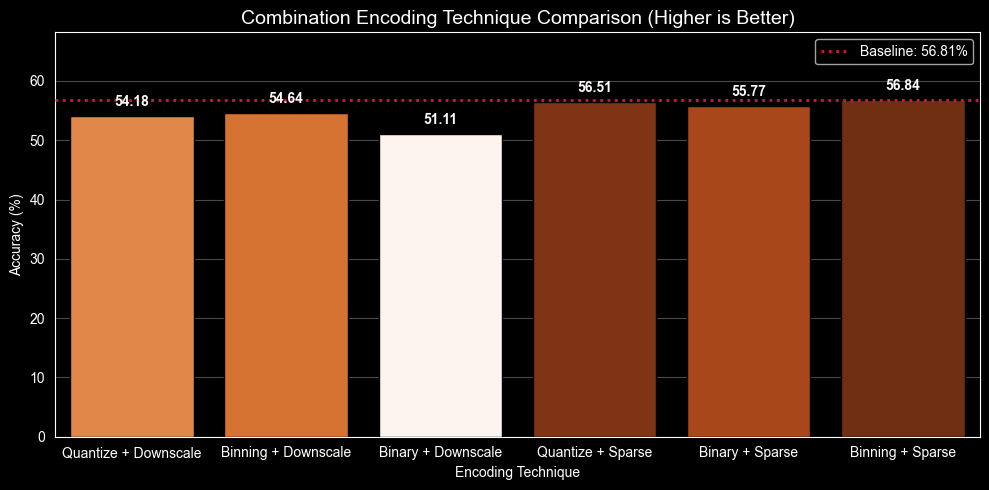

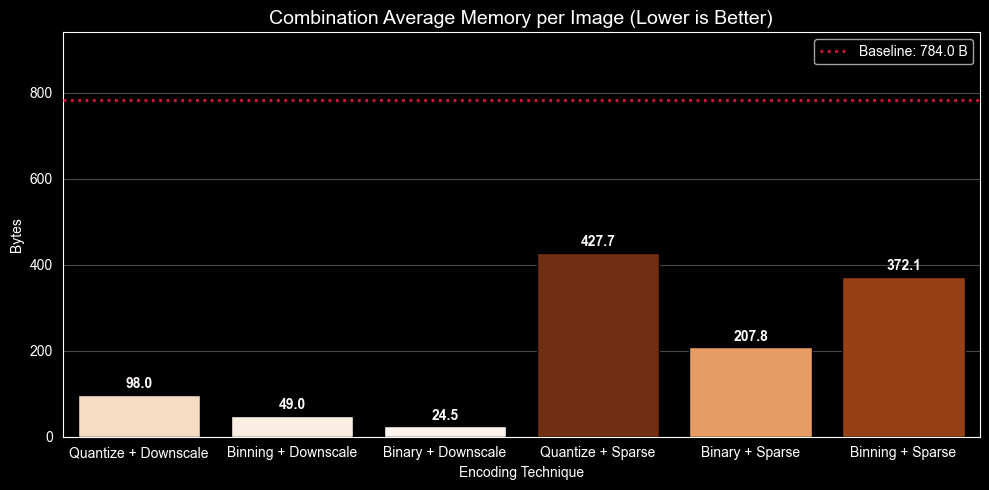

In [11]:
combination_results = data_representation.benchmark_combinations(clf, x_test, y_test)
data_representation_output.plot_encoding_comparison(
    combination_results,
    title_prefix="Combination",
    baseline_accuracy=results["Baseline"]["accuracy"] * 100,
    baseline_bytes=results["Baseline"]["avg_bytes"]
)

### Analyzing the Results
The benchmark results reveal a clear pattern. Quantization, binning, and sparse encoding each keep accuracy as close to the baseline as possible while reducing memory usage. Quantization and binning offer more predictable reductions. Sparse encoding's effectiveness varies heavily on both image content and how the features are designed. When it comes to image content, the more sparse the image is, the more effective sparse encoding becomes. When it comes to feature design, with what we currently have, sparse encoding, as well as downscaling, suffer from a crucial hidden cost: the reconstruction step. Because our features require a 28x28 image, we need to reconstruct the image back to its original size before we can perform inference. This means that both the techniques keep both the reduced and reconstructed image in RAM, meaning they take up more memory than the baseline. This is a significant drawback, and if we were to use either of these techniques on the device, we would need to redesign our features to accept the images as they are encoded. For the sake of simplicity, we will not explore this further for now, but it is important to consider how we would design our features to handle this. Apart from this hidden cost, downscaling also suffers from the worst accuracy loss, at a loss of 2.59%.
Binary thresholding, though dropping accuracy by a full 1 percentage point, offers by far the most significant memory reduction, mking it a strong candidate if memory constraints ever become a more significant concern. The combinations of techniques show that we can achieve even greater memory savings, though it would require careful selection to avoid compounding accuracy losses. To paint a picture, we can get from our baseline of 784 bytes down to 24.5 bytes using the combination of binary thresholding and downscaling, but we lose 5.7 percentage points in accuracy, which is a significant drop. Binning and sparse encoding together look like a great option, until we look at the actual numbers. Binning alone reduces memory usage to 196 bytes without losing accuracy. The same is true for the combination of binning and sparse encoding, but the memory usage goes up to 372.1 bytes, an increase of 176.1 bytes without any benefit, even before considering the reconstruction step.

All techniques have their own trade-offs, and the best choice we can make depends on how much memory we want to save and how much accuracy we are willing to sacrifice to achieve that. From these results, binning seems like the most straightforward technique to implement, as it offers a significant memory reduction without any loss in accuracy.

## Conclusion
We have explored various data representation techniques to reduce memory usage while retaining as much information as possible, all to answer the following question: **How can we represent the data in a way that is as small as possible, while retaining as much information as possible?**

The answer to this question is not as straightforward as we might have hoped. The definition "as small as possible" requires careful consideration on how it would play out in practice. From our current understanding, we can define "as small as possible" as the point where we can no longer reduce memory usage without hurting accuracy. This is a subjective definition, and we will likely need to revisit this baseline definition as we explore more techniques. For now, we can say that **binning** is the optimal choice for our use case, as it cuts memory usage by 75% without any loss in accuracy. It also requires no reconstruction step, meaning it is straightforward to implement and does not add any overhead during inference. Sparse encoding is second place in terms of accuracy, though the memory it saves is under 50% on average and is not consistent across images. Quantization is a close third, and it offers a consistent 50% reduction in memory usage, but it is not quite as accurate as binning.
The most aggressive techniques, such as binary thresholding and downscaling, offer significant memory reductions, but they come at the cost of a significant drop in accuracy. This drop in accuracy may be acceptable in some use cases. However, considering our tree with a depth of 11 is 134.70 KB, we have a lot of headroom to work with, allowing us to prioritize accuracy over memory savings for now.

What this exercise reveals is that the choice of representation is tightly coupled to the model's features and architecture. Because our features are rather simple, they do not require a high level of detail in the input images to perform well, which is why techniques like binning can reduce memory usage without hurting accuracy. If we were to use more complex features that zoom in on finer details of the digits, we might find that binning or quantization might hurt accuracy more significantly. We might need to explore other techniques that preserve more detail. In one such case, we might find that downscaling to a slightly larger size, such as 20x20, might be a better option than binning, as it would preserve some of the finer details. For now, we will stick with binning as our go-to technique, but we will keep exploring other techniques as we continue to iterate on our models and features.